In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [21]:
#Datasets and Dataloaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

#Image => scale(0,1) => Normalize => (-1,1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(
    root="/content/drive/MyDrive/Colab Notebooks/Deep Learning/datasets",
    train=True,
    download=False,
    transform=transform
)

testset = CIFAR10(
    root="/content/drive/MyDrive/Colab Notebooks/Deep Learning/datasets",
    train=False,
    download=False,
    transform=transform
)

In [22]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# Build the **CNN**

In [23]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.fc_layers = nn.Sequential(
        nn.Linear(4*4*128, 256),
        nn.ReLU(),

        nn.Linear(256, 10)
    )

  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0), -1) #Flattening Step
    x = self.fc_layers(x)

    return x

In [24]:
model = CNN()

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# **Train the CNN**

In [26]:
model = CNN() # Re-instantiate to include fixed forward method
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

epochs = 10

for epoch in range(epochs):
  epoch_training_loss = 0.0

  for images, labels in trainloader:
    optimizer.zero_grad()

    output = model(images) # Using model(images) is preferred over model.forward(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    epoch_training_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_training_loss/len(trainloader):.4f}")

Epoch 1/10, Loss: 1.3893
Epoch 2/10, Loss: 0.9535
Epoch 3/10, Loss: 0.7599
Epoch 4/10, Loss: 0.6337
Epoch 5/10, Loss: 0.5185
Epoch 6/10, Loss: 0.4284
Epoch 7/10, Loss: 0.3388
Epoch 8/10, Loss: 0.2633
Epoch 9/10, Loss: 0.2014
Epoch 10/10, Loss: 0.1608


## **Evaluate our CNN**

In [31]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
  for images, labels in testloader:
    output = model(images)
    _, predicted = torch.max(output.data, 1)

    total_labels += labels.size(0)
    correct_labels += (predicted == labels).sum().item()

print(f"Accuracy = {correct_labels/total_labels * 100}%")

Accuracy = 75.5%


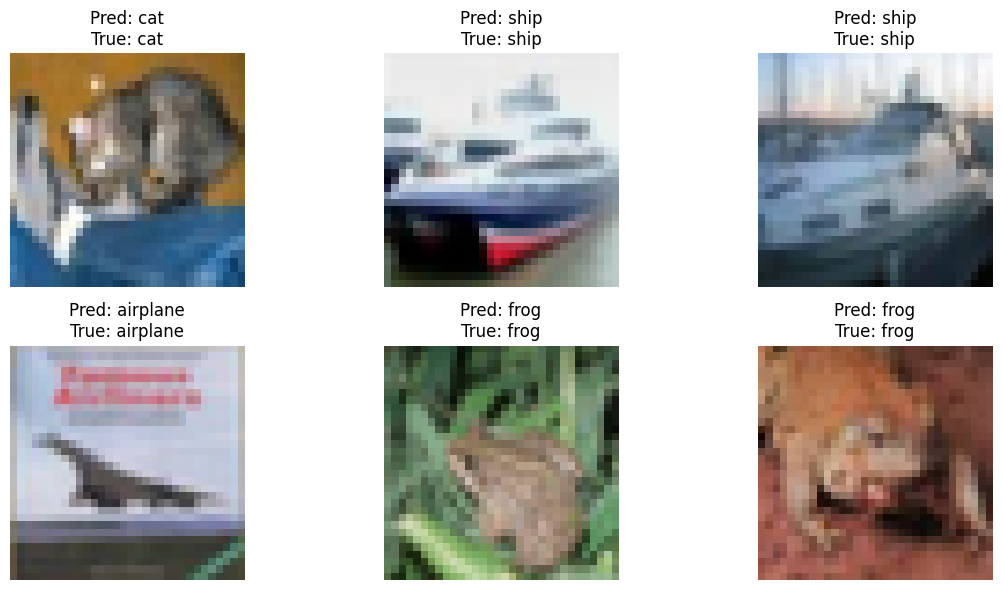

In [30]:
import matplotlib.pyplot as plt
import torch

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Put model in evaluation mode
model.eval()

# Get one batch of test images
images, labels = next(iter(testloader))

# Predict
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Display first 6 predictions
plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)

    # Undo normalization
    img = images[i] * 0.5 + 0.5
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()